In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_style('darkgrid')
np.set_printoptions(precision=2)
warnings.filterwarnings("ignore")

import sklearn
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer, Binarizer, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, PowerTransformer
from sklearn.impute import SimpleImputer, KNNImputer

from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

from sklearn.model_selection import KFold, ShuffleSplit, LeaveOneOut, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
""" Semilla """
seed = 99

## DATOS ##

data=pd.read_csv('SAheartbis.csv')

data['chd'] = data['chd'].map({'Si': 1, 'No': 0})

data = data.drop(columns=["Unnamed: 0"]) ## depende de la versión la exporta

y=pd.DataFrame(data["chd"])
X=data.drop(columns="chd")


[X_train, X_test, y_train, y_test] = train_test_split(X, y, test_size = 0.30, random_state = 101)


In [ ]:
display(X_train.head())
display(y_train.head())

,sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age,famhist_Present
93,-0.992806,0.079413,-0.382045,-0.829453,0.091375,-0.212423,-0.356351,0.423760,0
213,-0.309016,-0.792417,-1.817753,-0.516803,0.907127,0.167704,-0.696983,0.697861,0
278,-1.188175,-0.792417,-1.020138,-2.022154,-0.826346,-1.937250,-0.696983,-1.837577,0
225,0.228247,0.306089,0.057851,-0.233745,0.499251,-0.321709,0.068519,-0.055918,0
121,-0.895122,-0.487277,0.729782,-0.635172,0.703189,-0.046117,-0.348990,-1.015273,0


,chd
93,1
213,0
278,0
225,0
121,0


In [ ]:
from sklearn.ensemble import StackingClassifier
# Inicializar los modelos base
model_1 = RandomForestClassifier(random_state=42)
model_2 = LogisticRegression(random_state=42)
model_3 = SVC(probability=True)


# putting all base model objects in one list
all_models = [('rf', model_1), ('lr', model_2), ('SVC', model_3)]


# Inicializar el modelo de stacking
#stacking_model = StackingClassifier(
#    estimators=[('rf', model_1), ('lr', model_2), ('knn', model_3)],
#    final_estimator=SVC(kernel='linear', probability=True)
#)

In [ ]:
stacking_model = StackingClassifier(
    all_models,
    final_estimator=SVC(kernel='linear', probability=True)
)
stacking_model

StackingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('lr', LogisticRegression(random_state=42)),
                               ('SVC', SVC(probability=True))],
                   final_estimator=SVC(kernel='linear', probability=True))

In [ ]:
stacking_model.fit(X_train, y_train)
coefficients = stacking_model.final_estimator_.coef_
intercept = stacking_model.final_estimator_.intercept_


In [ ]:
print(coefficients)
print(intercept)

[[-0.47  2.08  2.02]]
[-1.85]


NO ME GUSTAN MUCHO ESOS NUMEROS


In [ ]:
# Obtener las características metaaprendidas por cada clasificador base
X_train_meta = stacking_model.transform(X_train)

In [ ]:
display(X_train_meta)

array([[0.66, 0.2 , 0.19],
       [0.03, 0.18, 0.23],
       [0.14, 0.04, 0.23],
       [0.13, 0.29, 0.23],
       [0.04, 0.15, 0.18],
       [0.84, 0.56, 0.7 ],
       [0.13, 0.44, 0.23],
       [0.29, 0.72, 0.55],
       [0.15, 0.31, 0.23],
       [0.83, 0.71, 0.77],
       [0.27, 0.41, 0.28],
       [0.18, 0.66, 0.27],
       [0.04, 0.06, 0.23],
       [0.8 , 0.79, 0.73],
       [0.1 , 0.16, 0.23],
       [0.79, 0.64, 0.7 ],
       [0.15, 0.22, 0.21],
       [0.59, 0.15, 0.22],
       [0.04, 0.06, 0.22],
       [0.19, 0.53, 0.43],
       [0.05, 0.05, 0.23],
       [0.75, 0.83, 0.7 ],
       [0.08, 0.35, 0.23],
       [0.04, 0.05, 0.23],
       [0.08, 0.06, 0.2 ],
       [0.01, 0.12, 0.22],
       [0.75, 0.14, 0.17],
       [0.08, 0.16, 0.19],
       [0.03, 0.03, 0.23],
       [0.03, 0.04, 0.2 ],
       [0.78, 0.44, 0.35],
       [0.11, 0.36, 0.21],
       [0.74, 0.42, 0.41],
       [0.03, 0.22, 0.2 ],
       [0.14, 0.3 , 0.23],
       [0.79, 0.56, 0.65],
       [0.13, 0.41, 0.23],
 

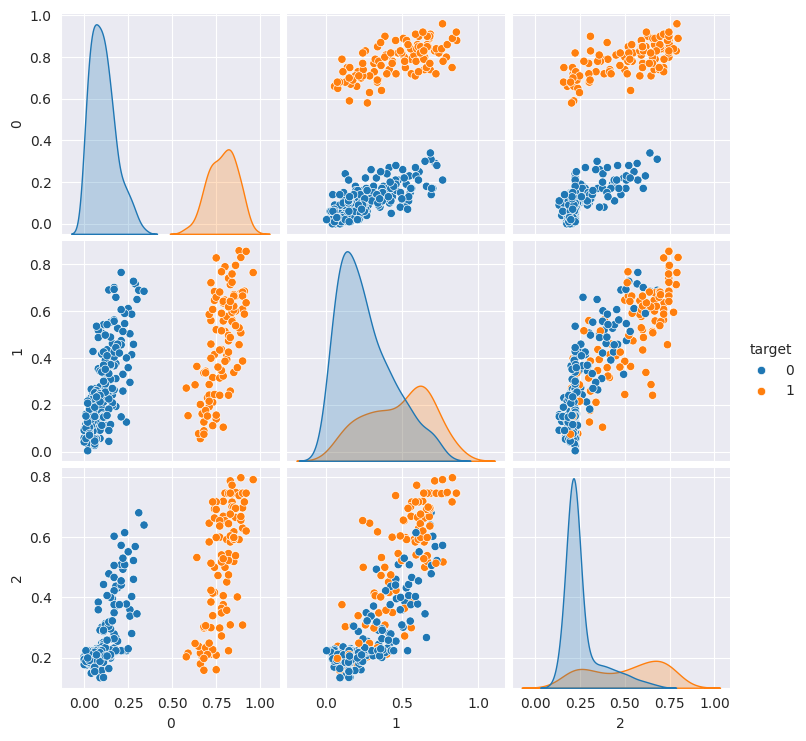

In [ ]:
# prompt: quiero dibujar sns los datos X_train_meta contra la variable target y_train con un pairplot

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convertir X_train_meta a un DataFrame para facilitar el uso de pairplot
X_train_meta_df = pd.DataFrame(X_train_meta)

# Agregar la columna target al DataFrame
X_train_meta_df['target'] = y_train.values

# Crear el pairplot
sns.pairplot(X_train_meta_df, hue='target', diag_kind='kde')
plt.show()


              precision    recall  f1-score   support

           0       0.71      0.91      0.80        86
           1       0.72      0.40      0.51        53

    accuracy                           0.71       139
   macro avg       0.72      0.65      0.65       139
weighted avg       0.71      0.71      0.69       139



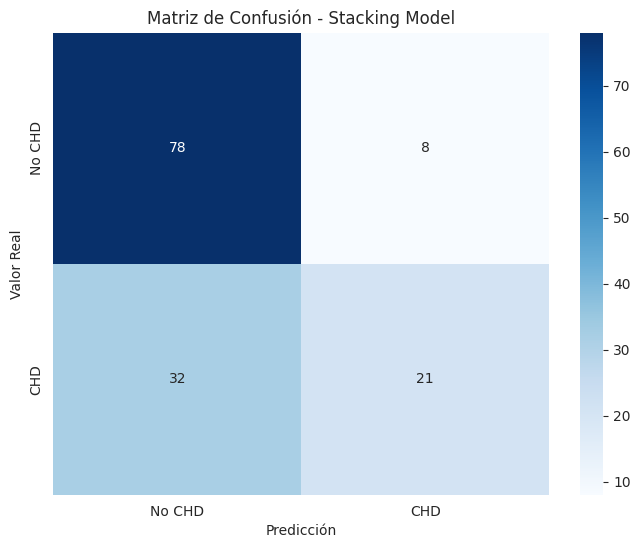

In [ ]:
# Entrenar el modelo de stacking
stacking_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = stacking_model.predict(X_test)

# Mostrar el classification report
print(classification_report(y_test, y_pred))

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar la matriz de confusión como un heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Stacking Model')
plt.show()


¿
HA MERECIDO LA PENA?



Resultados del Clasificador Base rf:
              precision    recall  f1-score   support

           0       0.70      0.86      0.77        86
           1       0.65      0.42      0.51        53

    accuracy                           0.69       139
   macro avg       0.68      0.64      0.64       139
weighted avg       0.68      0.69      0.67       139



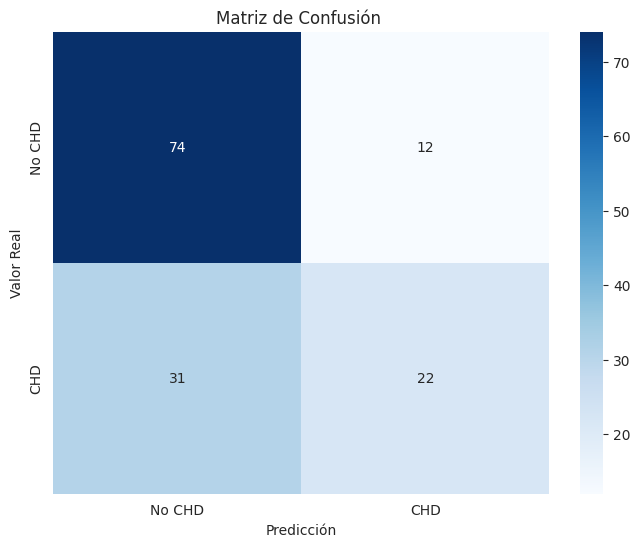


Resultados del Clasificador Base lr:
              precision    recall  f1-score   support

           0       0.70      0.91      0.79        86
           1       0.71      0.38      0.49        53

    accuracy                           0.71       139
   macro avg       0.71      0.64      0.64       139
weighted avg       0.71      0.71      0.68       139



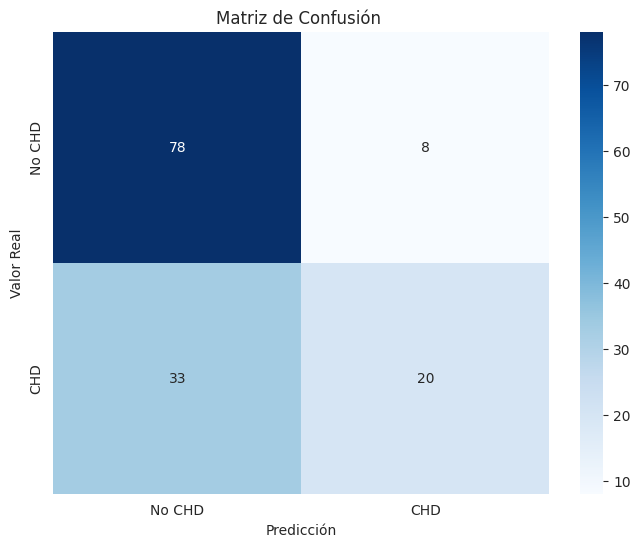


Resultados del Clasificador Base knn:
              precision    recall  f1-score   support

           0       0.69      0.90      0.78        86
           1       0.67      0.34      0.45        53

    accuracy                           0.68       139
   macro avg       0.68      0.62      0.61       139
weighted avg       0.68      0.68      0.65       139



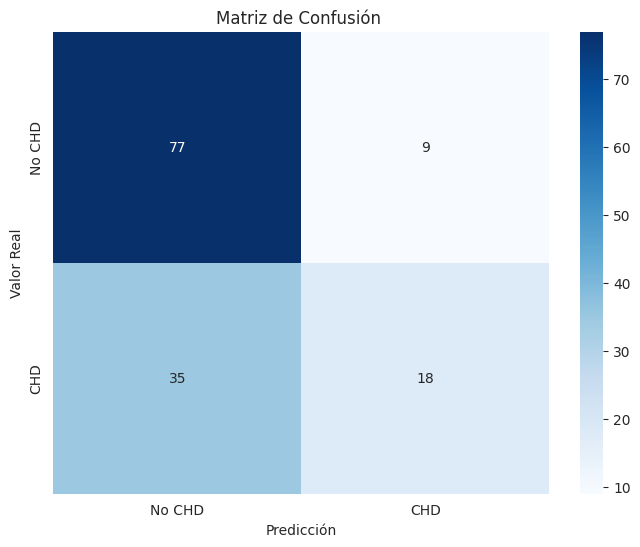

In [ ]:
# Obtener los clasificadores internos
base_classifiers = stacking_model.estimators_

# Obtener las características metaaprendidas por cada clasificador base
X_train_meta = stacking_model.transform(X_train)

# Evaluar el rendimiento de cada clasificador base individualmente
for (name, clf) in stacking_model.named_estimators_.items():
    clf.fit(X_train, y_train)
    y_pred_base = clf.predict(X_test)
    print(f"\nResultados del Clasificador Base {name}:")
    print(classification_report(y_test, y_pred_base))
    #print(f"Accuracy del Clasificador Base {name}: {accuracy_score(y_test, y_pred_base)}")
    # Calcular la matriz de confusión
    cm = confusion_matrix(y_test, y_pred_base)
    # Mostrar la matriz de confusión como un heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'])
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.title('Matriz de Confusión ')
    plt.show()


POR POCO PERO EL STACKING HA MEJORADO LOS MODELOS ANTERIORES



Resultados del Clasificador Base EN TRAIN rf:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       216
           1       1.00      1.00      1.00       107

    accuracy                           1.00       323
   macro avg       1.00      1.00      1.00       323
weighted avg       1.00      1.00      1.00       323



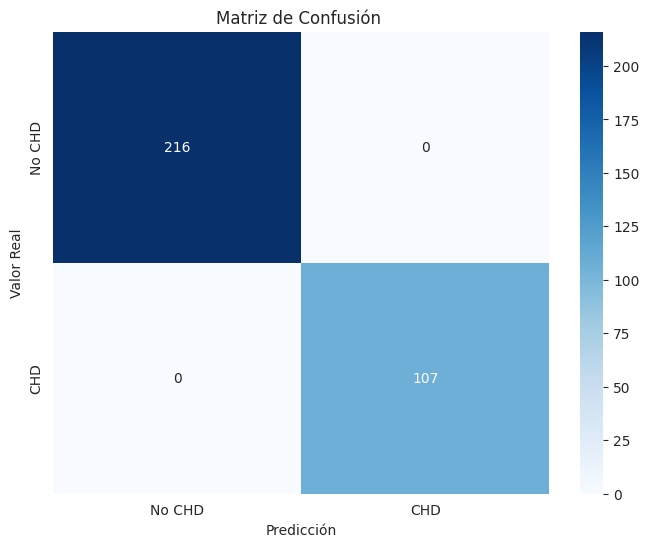


Resultados del Clasificador Base EN TRAIN lr:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       216
           1       0.67      0.52      0.59       107

    accuracy                           0.76       323
   macro avg       0.73      0.70      0.71       323
weighted avg       0.75      0.76      0.75       323



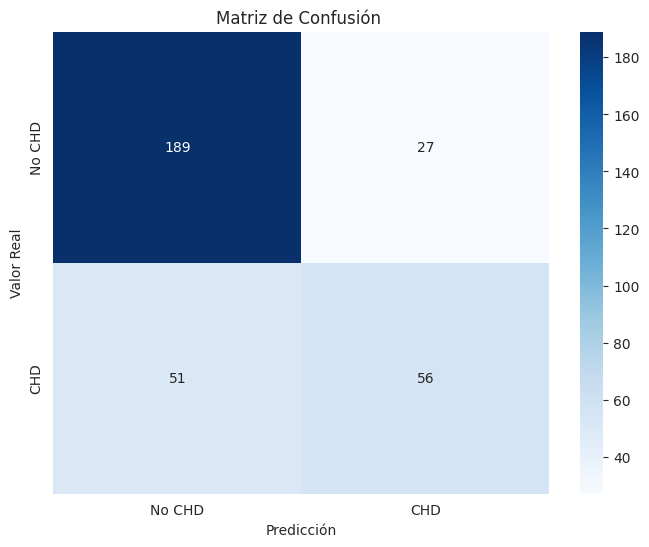


Resultados del Clasificador Base EN TRAIN knn:
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       216
           1       0.76      0.57      0.65       107

    accuracy                           0.80       323
   macro avg       0.79      0.74      0.76       323
weighted avg       0.79      0.80      0.79       323



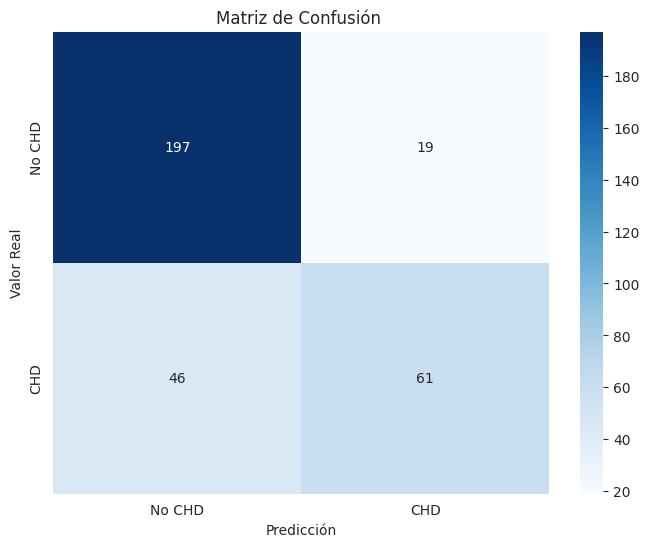

In [ ]:
# Obtener los clasificadores internos
base_classifiers = stacking_model.estimators_

# Obtener las características metaaprendidas por cada clasificador base
X_train_meta = stacking_model.transform(X_train)

# Evaluar el rendimiento de cada clasificador base individualmente
for (name, clf) in stacking_model.named_estimators_.items():
    clf.fit(X_train, y_train)
    y_pred_base = clf.predict(X_train)
    print(f"\nResultados del Clasificador Base EN TRAIN {name}:")
    print(classification_report(y_train, y_pred_base))
    #print(f"Accuracy del Clasificador Base {name}: {accuracy_score(y_test, y_pred_base)}")
    # Calcular la matriz de confusión
    cm = confusion_matrix(y_train, y_pred_base)
    # Mostrar la matriz de confusión como un heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'])
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.title('Matriz de Confusión ')
    plt.show()

In [ ]:
stacking_model = StackingClassifier(
    estimators=[('lr', model_2), ('knn', model_3)],
    final_estimator=SVC(kernel='linear', probability=True)
)

stacking_model.fit(X_train, y_train)
coefficients = stacking_model.final_estimator_.coef_
intercept = stacking_model.final_estimator_.intercept_

print(coefficients)
print(intercept)

[[3.08 0.16]]
[-1.71]


              precision    recall  f1-score   support

           0       0.70      0.91      0.79        86
           1       0.71      0.38      0.49        53

    accuracy                           0.71       139
   macro avg       0.71      0.64      0.64       139
weighted avg       0.71      0.71      0.68       139



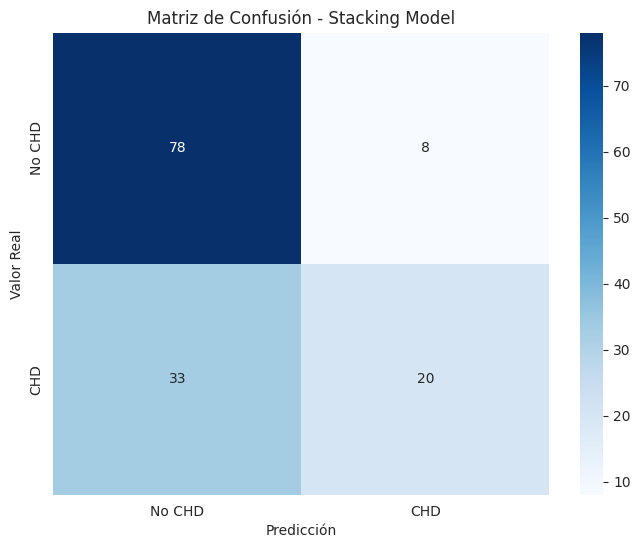

In [ ]:

# Realizar predicciones en el conjunto de prueba
y_pred = stacking_model.predict(X_test)

# Mostrar el classification report
print(classification_report(y_test, y_pred))

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar la matriz de confusión como un heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Stacking Model')
plt.show()


Resultados del Clasificador Base lr:
              precision    recall  f1-score   support

           0       0.70      0.91      0.79        86
           1       0.71      0.38      0.49        53

    accuracy                           0.71       139
   macro avg       0.71      0.64      0.64       139
weighted avg       0.71      0.71      0.68       139



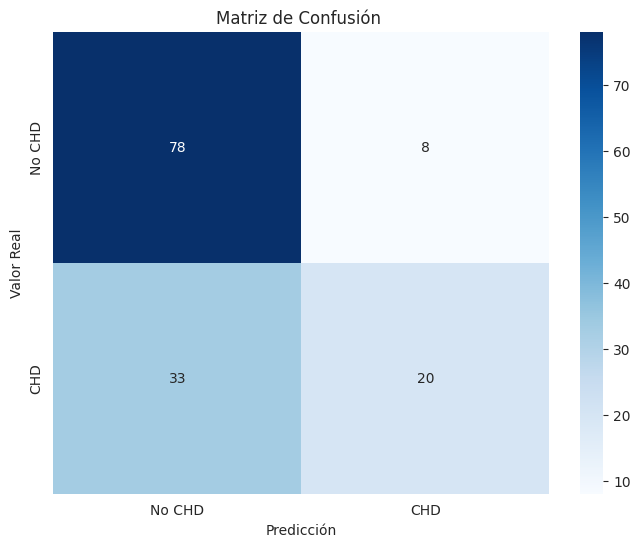


Resultados del Clasificador Base knn:
              precision    recall  f1-score   support

           0       0.67      0.80      0.73        86
           1       0.53      0.36      0.43        53

    accuracy                           0.63       139
   macro avg       0.60      0.58      0.58       139
weighted avg       0.62      0.63      0.61       139



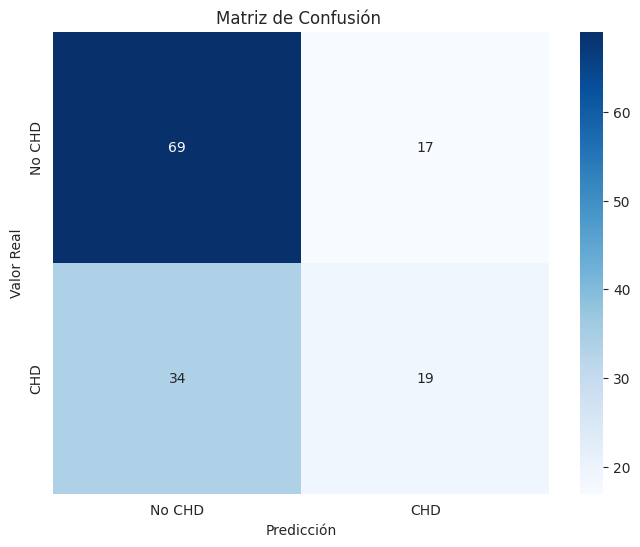

In [ ]:
# Obtener los clasificadores internos
base_classifiers = stacking_model.estimators_

# Obtener las características metaaprendidas por cada clasificador base
X_train_meta = stacking_model.transform(X_train)

# Evaluar el rendimiento de cada clasificador base individualmente
for (name, clf) in stacking_model.named_estimators_.items():
    clf.fit(X_train, y_train)
    y_pred_base = clf.predict(X_test)
    print(f"\nResultados del Clasificador Base {name}:")
    print(classification_report(y_test, y_pred_base))
    #print(f"Accuracy del Clasificador Base {name}: {accuracy_score(y_test, y_pred_base)}")
    # Calcular la matriz de confusión
    cm = confusion_matrix(y_test, y_pred_base)
    # Mostrar la matriz de confusión como un heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'])
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.title('Matriz de Confusión ')
    plt.show()

In [60]:

# Configurar el StackingClassifier
stacking_model = StackingClassifier(
    estimators=[('rf', model_1), ('lr', model_2), ('knn', model_3)],
    final_estimator=RandomForestClassifier(random_state=42),
    stack_method='auto',  # Puedes ajustar esto según tus necesidades
    cv=5,  # Validación cruzada interna
    passthrough=True  # Pasa las características originales al clasificador final
)

# Entrenar el modelo de stacking
stacking_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = stacking_model.predict(X_test)

# Mostrar el classification report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.71      0.90      0.79        86
           1       0.70      0.40      0.51        53

    accuracy                           0.71       139
   macro avg       0.70      0.65      0.65       139
weighted avg       0.70      0.71      0.68       139



In [62]:

##### BLENDING !!!
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score
from scipy.optimize import minimize

# Inicializar los modelos base
model_1 = RandomForestClassifier(random_state=42)
model_2 = LogisticRegression(random_state=42)
model_3 = KNeighborsClassifier()
# Poner todos los objetos de modelos base en una lista
all_models = [model_1, model_2, model_3]

# Entrenar los modelos base en el conjunto de entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=101)
for model in all_models:
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    print(f"Accuracy for model {model} on Train: {accuracy_train}")
    print(f"Accuracy for model {model} on Test: {accuracy_test}")


# Explorar diferentes combinaciones de pesos manualmente en el conjunto de entrenamiento
best_metric = 0.0
best_weights = None
# Inicializar el diccionario para almacenar los valores de accuracy para cada combinación de pesos
accuracy_values = {}

for w1 in range(0, 101, 10):
    for w2 in range(0, 101 - w1, 10):
        w3 = 100 - w1 - w2
        weights = [w1/100, w2/100, w3/100]

        # Crear y entrenar el modelo de blending final con los pesos actuales
        blending_model = VotingClassifier(
            estimators=[('model_1', model_1), ('model_2', model_2), ('model_3', model_3)],
            voting='soft',
            weights=weights
        )

        blending_model.fit(X_train, y_train)

        # Hacer predicciones en el conjunto de entrenamiento
        y_pred_proba_train = blending_model.predict_proba(X_train)

        # Calcular la métrica en el conjunto de entrenamiento (en este caso, accuracy)
        metric_train = accuracy_score(y_train, y_pred_proba_train.argmax(axis=1))

        # Actualizar la mejor combinación de pesos si se encuentra una métrica mejor en el conjunto de entrenamiento
        if metric_train > best_metric:
            best_metric = metric_train
            best_weights = weights
        # Almacenar la métrica para la combinación de pesos actual
        accuracy_values[tuple(weights)] = metric_train


# Imprimir los valores de accuracy para cada combinación de pesos
print("\nAccuracy Values:")
for weights, accuracy in accuracy_values.items():
    print(f"Weights: {weights}, Accuracy: {accuracy}")

# Imprimir las precisiones para el mejor modelo de blending en ambos conjuntos
print("\nBest Weights:", best_weights)
print("Best Metric on Training Set:", best_metric)

# Crear y entrenar el modelo de blending final con los mejores pesos en todo el conjunto de entrenamiento
final_blending_model = VotingClassifier(
    estimators=[('model_1', model_1), ('model_2', model_2), ('model_3', model_3)],
    voting='soft',
    weights=best_weights
)

final_blending_model.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred_proba_test = final_blending_model.predict_proba(X_test)

# Calcular la métrica final en el conjunto de prueba (en este caso, accuracy)
final_metric_test = accuracy_score(y_test, y_pred_proba_test.argmax(axis=1))

# Imprimir la métrica final en el conjunto de prueba
print("Final Metric on Test Set:", final_metric_test)

Accuracy for model RandomForestClassifier(random_state=42) on Train: 1.0
Accuracy for model RandomForestClassifier(random_state=42) on Test: 0.6666666666666666
Accuracy for model LogisticRegression(random_state=42) on Train: 0.7452574525745257
Accuracy for model LogisticRegression(random_state=42) on Test: 0.6881720430107527
Accuracy for model KNeighborsClassifier() on Train: 0.7913279132791328
Accuracy for model KNeighborsClassifier() on Test: 0.6344086021505376

Accuracy Values:
Weights: (0.0, 0.0, 1.0), Accuracy: 0.7913279132791328
Weights: (0.0, 0.1, 0.9), Accuracy: 0.7913279132791328
Weights: (0.0, 0.2, 0.8), Accuracy: 0.7940379403794038
Weights: (0.0, 0.3, 0.7), Accuracy: 0.8021680216802168
Weights: (0.0, 0.4, 0.6), Accuracy: 0.7994579945799458
Weights: (0.0, 0.5, 0.5), Accuracy: 0.7967479674796748
Weights: (0.0, 0.6, 0.4), Accuracy: 0.7913279132791328
Weights: (0.0, 0.7, 0.3), Accuracy: 0.7859078590785907
Weights: (0.0, 0.8, 0.2), Accuracy: 0.7777777777777778
Weights: (0.0, 0.9,

NO VALE PARA NADA


In [67]:

from sklearn.model_selection import KFold

# Explorar diferentes combinaciones de pesos manualmente en el conjunto de entrenamiento con validación cruzada
best_metric = 0.0
best_weights = None
# Inicializar el diccionario para almacenar los valores de accuracy para cada combinación de pesos
accuracy_values = {}

# Crear un objeto KFold para la validación cruzada
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # Puedes ajustar n_splits según tus necesidades

for w1 in range(0, 101, 10):
    for w2 in range(0, 101 - w1, 10):
        w3 = 100 - w1 - w2
        weights = [w1/100, w2/100, w3/100]

        # Inicializar una lista para almacenar las métricas de cada pliegue
        fold_metrics = []

        # Iterar sobre los pliegues de la validación cruzada
        for train_index, val_index in kf.split(X_train):
            X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
            y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

            # Crear y entrenar el modelo de blending final con los pesos actuales
            blending_model = VotingClassifier(
                estimators=[('model_1', model_1), ('model_2', model_2), ('model_3', model_3)],
                voting='soft',
                weights=weights
            )

            blending_model.fit(X_train_fold, y_train_fold)

            # Hacer predicciones en el conjunto de validación
            y_pred_proba_val = blending_model.predict_proba(X_val_fold)

            # Calcular la métrica en el conjunto de validación (en este caso, accuracy)
            metric_val = accuracy_score(y_val_fold, y_pred_proba_val.argmax(axis=1))

            # Agregar la métrica del pliegue a la lista
            fold_metrics.append(metric_val)

        # Calcular la métrica promedio de los pliegues
        metric_train = np.mean(fold_metrics)

        # Actualizar la mejor combinación de pesos si se encuentra una métrica mejor en el conjunto de entrenamiento
        if metric_train > best_metric:
            best_metric = metric_train
            best_weights = weights

        # Almacenar la métrica para la combinación de pesos actual
        accuracy_values[tuple(weights)] = metric_train

# Imprimir los valores de accuracy para cada combinación de pesos
print("\nAccuracy Values:")
for weights, accuracy in accuracy_values.items():
    print(f"Weights: {weights}, Accuracy: {accuracy}")

# Imprimir las precisiones para el mejor modelo de blending en ambos conjuntos
print("\nBest Weights:", best_weights)
print("Best Metric on Training Set:", best_metric)




Accuracy Values:
Weights: (0.0, 0.0, 1.0), Accuracy: 0.6259533506108849
Weights: (0.0, 0.1, 0.9), Accuracy: 0.6259533506108849
Weights: (0.0, 0.2, 0.8), Accuracy: 0.6286560533135874
Weights: (0.0, 0.3, 0.7), Accuracy: 0.6665309144761199
Weights: (0.0, 0.4, 0.6), Accuracy: 0.6774157719363199
Weights: (0.0, 0.5, 0.5), Accuracy: 0.6937060348019253
Weights: (0.0, 0.6, 0.4), Accuracy: 0.709959274342836
Weights: (0.0, 0.7, 0.3), Accuracy: 0.7262495372084412
Weights: (0.0, 0.8, 0.2), Accuracy: 0.7236208811551277
Weights: (0.0, 0.9, 0.1), Accuracy: 0.720918178452425
Weights: (0.0, 1.0, 0.0), Accuracy: 0.7182895223991114
Weights: (0.1, 0.0, 0.9), Accuracy: 0.6259533506108849
Weights: (0.1, 0.1, 0.8), Accuracy: 0.6286560533135874
Weights: (0.1, 0.2, 0.7), Accuracy: 0.6557201036653092
Weights: (0.1, 0.3, 0.6), Accuracy: 0.6692336171788227
Weights: (0.1, 0.4, 0.5), Accuracy: 0.685523880044428
Weights: (0.1, 0.5, 0.4), Accuracy: 0.7018141429100333
Weights: (0.1, 0.6, 0.3), Accuracy: 0.712699000370

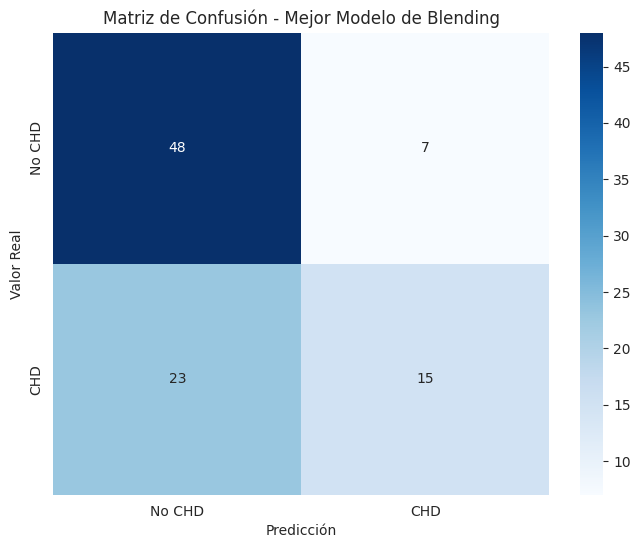

              precision    recall  f1-score   support

           0       0.68      0.87      0.76        55
           1       0.68      0.39      0.50        38

    accuracy                           0.68        93
   macro avg       0.68      0.63      0.63        93
weighted avg       0.68      0.68      0.65        93



In [65]:
# Crear y entrenar el modelo de blending final con los mejores pesos en todo el conjunto de entrenamiento
final_blending_model = VotingClassifier(
    estimators=[('model_1', model_1), ('model_2', model_2), ('model_3', model_3)],
    voting='soft',
    weights=best_weights
)

final_blending_model.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred = final_blending_model.predict(X_test)

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar la matriz de confusión como un heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Mejor Modelo de Blending')
plt.show()

# Mostrar el classification report
print(classification_report(y_test, y_pred))

In [68]:

######################### ahora vamos a tunear un poco el metaclasificador.
## Es igual a como se hace con cualquier modelo
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import make_scorer, accuracy_score


# Inicializar los clasificadores base
clf1 = RandomForestClassifier(random_state=42)
clf2 = LogisticRegression(random_state=42, max_iter=1000)
clf3 = KNeighborsClassifier()

# Inicializar el clasificador final
final_estimator = LogisticRegression(random_state=42, max_iter=1000)

# Configurar el StackingClassifier
stacking_model = StackingClassifier(
    estimators=[('rf', clf1), ('lr', clf2), ('knn', clf3)],
    final_estimator=final_estimator,
    stack_method='auto',
    cv=5,
    passthrough=True
)

# Definir la cuadrícula de parámetros para la búsqueda
param_grid = {'final_estimator__C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Definir la métrica que deseas optimizar (por ejemplo, precisión)
scoring = make_scorer(accuracy_score)

# Realizar la búsqueda de cuadrícula para encontrar la mejor combinación de pesos
grid_search = GridSearchCV(stacking_model, param_grid, scoring=scoring, cv=5)
grid_search.fit(X_train, y_train)

# Obtener el mejor modelo y sus parámetros
best_stacking_model = grid_search.best_estimator_
best_params = grid_search.best_params_

# Evaluar el rendimiento del mejor modelo en el conjunto de prueba
y_pred_best = best_stacking_model.predict(X_test)
print("\nResultados del Mejor Modelo:")
print(classification_report(y_test, y_pred_best))
print("Mejores parámetros:", best_params)


Resultados del Mejor Modelo:
              precision    recall  f1-score   support

           0       0.68      0.89      0.77        55
           1       0.71      0.39      0.51        38

    accuracy                           0.69        93
   macro avg       0.70      0.64      0.64        93
weighted avg       0.69      0.69      0.66        93

Mejores parámetros: {'final_estimator__C': 0.1}
